In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("7-)diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df.drop(df[df["x"]==0].index, inplace=True)

In [7]:
df.drop(df[df["y"]==0].index, inplace=True)

In [8]:
df.drop(df[df["z"]==0].index, inplace=True)

In [9]:
df.describe()

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
df.duplicated().sum()

np.int64(145)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
X= df.drop("price", axis=1)
y= df["price"]

In [14]:
cat_col= X.select_dtypes(include=["object"]).columns
num_col= X.select_dtypes(exclude=["object"]).columns
cat_col

Index(['cut', 'color', 'clarity'], dtype='object')

In [15]:
for i  in cat_col:
    print(df[i].value_counts())

cut
Ideal        21485
Premium      13737
Very Good    12068
Good          4888
Fair          1597
Name: count, dtype: int64
color
G    11254
E     9776
F     9517
H     8266
D     6754
I     5406
J     2802
Name: count, dtype: int64
clarity
SI1     13030
VS2     12225
SI2      9142
VS1      8155
VVS2     5056
VVS1     3646
IF       1784
I1        737
Name: count, dtype: int64


In [16]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [17]:
num_col

Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object')

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor= ColumnTransformer(transformers=[
    ("num_col", StandardScaler(), num_col),
    ("cat_col", OneHotEncoder(drop="first"), cat_col)
], remainder="passthrough")

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [21]:
model_dic={
    "Linear Regression" : LinearRegression(),
    "SVM" : SVR(),
    "KNN" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Ada Boost" : AdaBoostRegressor(),
    "Gradient Boost" : GradientBoostingRegressor(),
    "Random Forest" : RandomForestRegressor(), 
    "XGBoost" : XGBRegressor(), 
    "LightGBM" : LGBMRegressor()
}

model_score={}

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [23]:
for name, model in model_dic.items():

    model_pipe=Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    model_pipe.fit(X_train, y_train)
    y_pred= model_pipe.predict(X_test)

    r2= r2_score(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)

    train_score= model_pipe.score(X_train, y_train)
    test_score= model_pipe.score(X_test, y_test)

    model_score[name]=r2
    
    print(name)
    print(f"R2_Score={r2}")
    print(f"Mean Squared Error={MSE}")
    print(f"Mean Absolute Error={MAE}")
    print(f"Train Score={train_score}")
    print(f"Test Score={test_score}")
    print("--------------------------\n\n")

Linear Regression
R2_Score=0.9179368538479489
Mean Squared Error=1281992.6780177238
Mean Absolute Error=735.0014016415716
Train Score=0.920933758981813
Test Score=0.9179368538479489
--------------------------


SVM
R2_Score=0.5040733833324096
Mean Squared Error=7747378.954055155
Mean Absolute Error=1324.6545784443085
Train Score=0.5027807439210004
Test Score=0.5040733833324096
--------------------------


KNN
R2_Score=0.9537169413165457
Mean Squared Error=723035.1885182982
Mean Absolute Error=431.2855548943767
Train Score=0.9720176631683473
Test Score=0.9537169413165457
--------------------------


Decision Tree
R2_Score=0.9534044928004118
Mean Squared Error=727916.2676472776
Mean Absolute Error=389.8584126747992
Train Score=0.9999954021978259
Test Score=0.9534044928004118
--------------------------


Ada Boost
R2_Score=0.8349804984091885
Mean Squared Error=2577939.0955542424
Mean Absolute Error=1093.9067453280857
Train Score=0.8435595070709636
Test Score=0.8349804984091885
-----------

In [24]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [25]:
Lgbm_pipe=Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(random_state=42))
])

lgbm_param={
    "model__n_estimators" : [100, 300 ,500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves" : [31, 50, 70],
    "model__max_depth" : [-1, 5, 15],
    "model__min_child_samples" : [10, 20, 30],
    "model__subsample" : [0.8, 1],
    "model__colsample_bytree" : [0.8, 1]
}

lgbm_grid= RandomizedSearchCV(estimator=Lgbm_pipe, param_distributions=lgbm_param, cv=5, n_jobs=-1, scoring="neg_mean_absolute_error", verbose=1, random_state=42)

lgbm_grid.fit(X_train, y_train)
y_pred= lgbm_grid.predict(X_test)

r2= r2_score(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

train_score= lgbm_grid.score(X_train, y_train)
test_score= lgbm_grid.score(X_test, y_test)

model_score[name]=r2
    

print(f"R2_Score={r2}")
print(f"Mean Squared Error={MSE}")
print(f"Mean Absolute Error={MAE}")
print(f"Train Scoring={train_score}")
print(f"Test Scoring={test_score}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1288
[LightGBM] [Info] Number of data points in the train set: 40331, number of used features: 23
[LightGBM] [Info] Start training from score 3933.684337
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
R2_Score=0.9804880994288558
Mean Squared Error=304815.43590918474
Mean Absolute Error=283.0311952051538
Train Scoring=-222.67580025837407
Test Scoring=-283.0311952051538


In [26]:
lgbm_grid.best_params_

{'model__subsample': 1,
 'model__num_leaves': 70,
 'model__n_estimators': 300,
 'model__min_child_samples': 10,
 'model__max_depth': 15,
 'model__learning_rate': 0.05,
 'model__colsample_bytree': 1}

In [27]:
best_gbm= lgbm_grid.best_estimator_

features= best_gbm["preprocessor"].get_feature_names_out()

importances= best_gbm["model"].feature_importances_

importance_df= pd.DataFrame({
    "Feature Name" : features, 
    "Importance" : importances
})

In [28]:
importance_df.sort_values(by="Importance", ascending=False)

,Feature Name,Importance
0,num_col__carat,2701
1,num_col__depth,2579
5,num_col__z,2539
4,num_col__y,2443
3,num_col__x,2205
2,num_col__table,1319
15,cat_col__color_J,650
18,cat_col__clarity_SI2,637
14,cat_col__color_I,620
13,cat_col__color_H,521


In [29]:
model_score["LightGBM Tuning"]=0.9798835792690364

In [30]:
score_df= pd.DataFrame(model_score.items(),
                      columns=["Model Name", "Score"])
score_df.sort_values(by="Score", ascending=False)

,Model Name,Score
8,LightGBM,0.980488
9,LightGBM Tuning,0.979884
7,XGBoost,0.977672
6,Random Forest,0.972574
2,KNN,0.953717
3,Decision Tree,0.953404
5,Gradient Boost,0.950672
0,Linear Regression,0.917937
4,Ada Boost,0.834980
1,SVM,0.504073


Performans skorları aynı görünse dahi mae, mse değerleri azaldı.

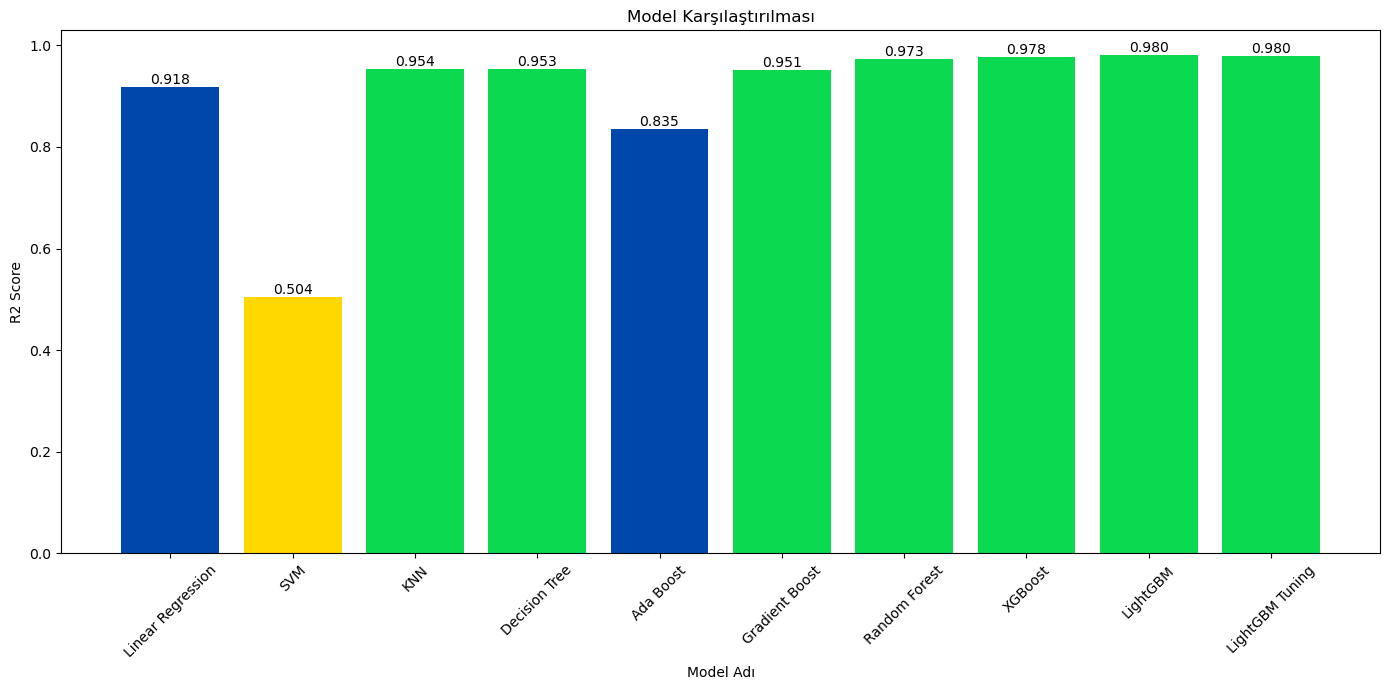

In [31]:
plt.figure(figsize=(14, 7))

renkler=["#0BDA51" if score > 0.95 
         else "#0047AB" if 0.95>= score > 0.8 
         else "#FFD800" if 0.8>= score > 0
         else "#B7410E"
         for score in score_df["Score"]]

bars = plt.bar(
    score_df["Model Name"],
    score_df["Score"],
    color=renkler
)

for bar in bars:
    score= bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score,
        f"{score:.3f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Model Adı")
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("Model Karşılaştırılması")


plt.tight_layout()
plt.show()

In [32]:
import pickle

In [33]:
with open("DiamondRegression.pkl", "wb") as file:
    pickle.dump(lgbm_grid.best_estimator_, file)

In [38]:
import shap

In [ ]:

# Pipeline`ın preprocessing kısmı
preprocessor = best_gbm["preprocessor"]

# Pipeline'ın LGBM modeli
model = best_gbm["model"]

# Veriyi dönüştür
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# SHAP explainer
explainer = shap.TreeExplainer(model)

# SHAP değerleri
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=features)
